# Function 2 Analysis - Week 1

This notebook contains the exploratory analysis for **Function 2** in Week 1. We examine the initial datapoints to understand the relationship between inputs (x1, x2) and the output (y).

**Function Description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.


## Loading and Displaying the Data

We load the initial inputs and outputs for function 2 and display them in a table format to inspect the raw data values. We can see that x1 and x2 seem already to be normalised as all values are in [0,1]. The output variable is mostly positive but also has 2 negatives. While the log of a a discrete probability distribution is normally negative, this suggests we are dealing with a continuous distribution, the density of which can be positive. Or alternatively, the log probabilities were inverted. 


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
df


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


## Correlation Heatmap

The correlation heatmap shows the pairwise correlations between all variables (x1, x2, and y). We can see good correlation betweenn all variables. The highest correlation is between x1 and y at 0.75. The correlation between x2 and y is much lower but seems significative (at 0.39). There is also correlation between x1 and x2 which we need to take into account in our modelling. 

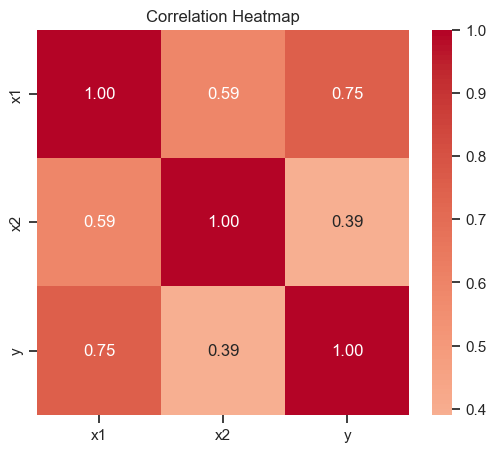

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Pairplot Analysis

The pairplot provides a comprehensive view of pairwise relationships between all variables. The diagonal shows the distribution of each variable (histograms), while the off-diagonal plots show scatter plots between pairs of variables. The charts confirm visually our result from the correlation matrix. There seems to be a strong positive correlation between x1 and y which takes a seemingly convex shape. The relationship between x2 and y seems much more random at this stage. The two highest y values are for one x2 low and one x2 high. 


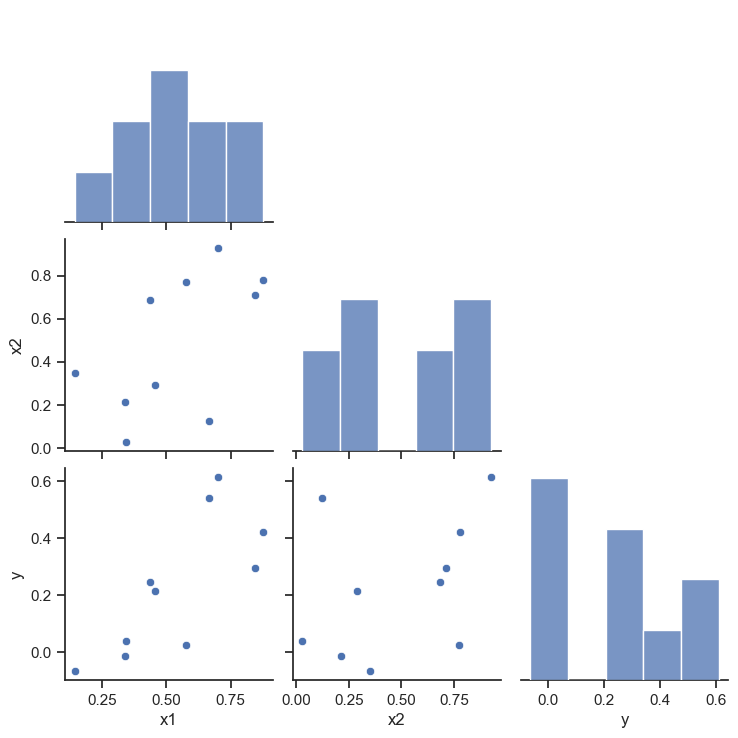

In [7]:
sns.pairplot(df, corner=True, diag_kind="hist")
plt.show()


## Input Space Visualization: x1 vs x2 coloured by y

This scatter plot shows the relationship between the two input variables (x1 and x2) with each point colored according to its output value (y). This visualization helps identify regions in the input space that yield high or low output values, revealing potential peaks, valleys, or patterns in the function landscape. We note the highest values are concentrated in the top right corner. As a consequence of the high correlation between x1 and x2, the scatter plot shows little space has been explored in the top left and bottom right corner (i.e. high x1 and low x2 or low x1 and high x2), except for one data point which is also significantly positive. This could indicate a second local minimum we need to explore. 


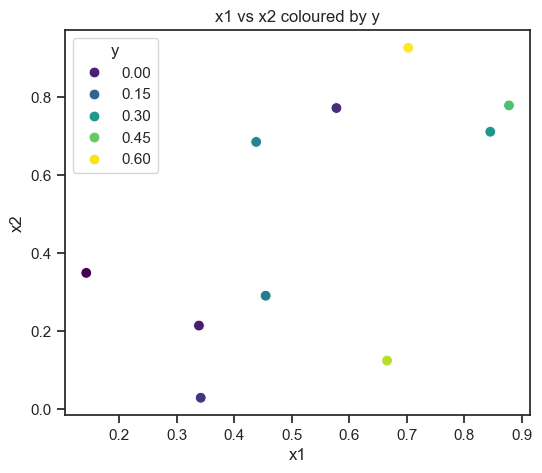

In [8]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="viridis", s=60)
plt.title("x1 vs x2 coloured by y")
plt.show()


## Analysis and recommendation

Our analysis shows a concentration of high output with x1 and x2 high, with one exception where x2 is low and x1 is high. This could hint to two local maxmima. The combination of low x1 and high x2 is largely unexplored also. Intriguingly, the highest value's closest neighbour seems to be a low output number. Visually the most promising white spaces seem to be 1/ around the highest value 2/ low x1, high x2 and 3/ around the second highest output. The last option seems to be a good compromise between exploration and exploitation as it could confirm the strong positive relationship between x1 and y further while also giving some insight around a big unexplored area. We pick x1 =  0.85 and x2 = 0.25